# Qualidade do Ar: FaseB: Design

Bem-vindo ao segundo laboratório deste curso. Na semana passada, você usou análise exploratória de dados para obter insights sobre os dados de qualidade do ar de Bogotá obtidos do [RMCAB](http://201.245.192.252:81/home/map). Neste caderno, você trabalhará na próxima etapa do seu projeto: projetar sua solução.

Aqui estão as etapas que você concluirá neste caderno:

1. Importe pacotes Python
2. Carregue os dados
3. Adicione localização (latitude e longitude das estações de sensores) ao dataframe
4. Visualize a extensão e distribuição dos dados faltantes
5. Visualize métodos simples para estimar valores ausentes
6. Execute o método do vizinho mais próximo para estabelecer uma linha de base
7. Prepare os dados para treinar um modelo de rede neural
8. Treine e teste um modelo de rede neural para estimar valores ausentes
9. Visualize os resultados do seu modelo de linha de base em comparação com a rede neural
10. Estime as medições faltantes dos sensores em todos os poluentes
11. Visualize os resultados do preenchimento dos valores PM2.5 ausentes
12. Opcional: grave o conjunto de dados resultante em um novo arquivo csv

## 1. Importar pacotes Python
Execute a próxima célula para importar os pacotes Python que você usará neste exercício de laboratório. Se tudo correr bem, você deverá ver uma mensagem quando a célula terminar de ser executada, dizendo "Todos os pacotes importados com sucesso!".
Observe a linha `import utils`. Esta linha importa as funções que foram escritas especificamente para este laboratório. Se você quiser ver quais são essas funções, vá em `Arquivo -> Abrir...` e abra o arquivo `utilitariosFaseB_implementacao` para dar uma olhada.



In [16]:
# Importar Pacotes
import pandas as pd # Ler e manipular dados
from datetime import datetime # Manipudar datas
from sklearn.model_selection import train_test_split # divisão de dados

import utilitariosFaseB_implementacao # Utilitários para este LAb

print('Todos pacotes importados com sucesso!')

Todos pacotes importados com sucesso!


## 2. Carregue os dados

Execute a próxima célula para carregar os dados de qualidade do ar de Bogotá. Esta é a mesma etapa que você executou no laboratório anterior, onde você está usando o pacote `pandas` para ler o arquivo csv contendo os dados em um "dataframe" chamado `raw_data`, depois modificando alguns dos nomes e formatos das colunas, e imprimindo as primeiras cinco linhas do dataframe.

In [17]:
# Ler os dados
raw_data = pd.read_csv('data/RMCAB_projetoCompleto.csv')
# Modificar o formato da coluna datetime
raw_data['DateTime'] = pd.to_datetime(utilitariosFaseB_implementacao.fix_dates(raw_data, 'DateTime'), dayfirst=True)
# Renomear colunas de Espanho para Inglês
raw_data = raw_data.rename(columns={'OZONO': 'OZONE'})
# Printar a quantidade de linhas de um dataset
print(f'-='*30)
print(f"O dataset contém {len(raw_data)} entradas")
print(f'-='*30)
# Printar as cinco primeiras linhas
raw_data.head(5)

-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
O dataset contém 166440 entradas
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=


,PM10,PM2.5,NO,NO2,NOX,CO,OZONE,Station,DateTime
0,56.6,32.7,7.504,15.962,23.493,0.44924,2.431,USM,2021-01-01 00:00:00
1,59.3,39.3,16.560,17.866,34.426,0.69832,1.121,USM,2021-01-01 01:00:00
2,96.4,70.8,22.989,17.802,40.791,0.88243,1.172,USM,2021-01-01 02:00:00
3,108.3,81.0,3.704,9.886,13.591,0.29549,6.565,USM,2021-01-01 03:00:00
4,87.7,56.1,2.098,9.272,11.371,0.16621,9.513,USM,2021-01-01 04:00:00


## 3. Adicione localização (latitude e longitude das estações de sensores) ao dataframe

Execute a próxima célula para ler outro conjunto de dados contendo a localização de cada estação de sensor e, em seguida, adicione esses locais como novas colunas ao seu conjunto de dados de poluição do ar.

**Observação:** os dados usados ​​aqui para adicionar a localização de cada estação incluem nomes de colunas em espanhol, como `Sigla` ​​(iniciais), `Latitud` (latitude), `Longitud` (longitude) e com a próxima célula você também está renomeando essas colunas para seu equivalente em inglês (com "estação" em vez de "iniciais").

In [18]:
# Leia o arquivo csv contendo dados de localização e formate adequadamente
stations = pd.read_csv('data/localizacaoEstacoes.csv')
stations = stations[['Sigla', 'Latitud', 'Longitud']]
# Renomeie as colunas de espanhol para inglês
stations = stations.rename(columns={'Sigla': 'Station', 'Latitud': 'Latitude', 'Longitud': 'Longitude'})
# 'Parse'. Analise as datas
stations['Latitude'] = stations['Latitude'].apply(utilitariosFaseB_implementacao.parse_dms)
stations['Longitude'] = stations['Longitude'].apply(utilitariosFaseB_implementacao.parse_dms)
# Adicione dados de localização como colunas extras ao conjunto de dados de poluição do ar
raw_data_enriched = pd.merge(raw_data, stations, on='Station', how='inner')
raw_data_enriched.head(5)

,PM10,PM2.5,NO,NO2,NOX,CO,OZONE,Station,DateTime,Latitude,Longitude
0,56.6,32.7,7.504,15.962,23.493,0.44924,2.431,USM,2021-01-01 00:00:00,4.532056,-74.117139
1,59.3,39.3,16.560,17.866,34.426,0.69832,1.121,USM,2021-01-01 01:00:00,4.532056,-74.117139
2,96.4,70.8,22.989,17.802,40.791,0.88243,1.172,USM,2021-01-01 02:00:00,4.532056,-74.117139
3,108.3,81.0,3.704,9.886,13.591,0.29549,6.565,USM,2021-01-01 03:00:00,4.532056,-74.117139
4,87.7,56.1,2.098,9.272,11.371,0.16621,9.513,USM,2021-01-01 04:00:00,4.532056,-74.117139


## 4. Visualize a extensão e distribuição dos dados ausentes

### 4.1 Contar valores nulos

Execute a próxima célula para realizar a contagem de valores nulos que você fez no último notebook como um lembrete de quantos valores ausentes existem em cada coluna do seu conjunto de dados.

In [19]:
# Imprima uma contagem de dados ausentes para cada coluna do conjunto de dados
raw_data_enriched.isnull().sum()

PM10         17889
PM2.5        13323
NO           26300
NO2          26297
NOX          26303
CO           29687
OZONE        28659
Station          0
DateTime         0
Latitude         0
Longitude        0
dtype: int64

### 4.2 Visualize dados ausentes em uma série temporal

Execute a célula abaixo para gerar o mesmo gráfico que você viu perto do final do último laboratório, ou seja, valores de poluentes ao longo do tempo medidos em uma estação de sensor específica. Você pode usar os menus suspensos para escolher diferentes estações e poluentes. Você também pode usar os controles deslizantes para aumentar ou diminuir o zoom em um determinado intervalo de datas. Você pode editar os valores `start_date` e `end_date` e executar a célula de código novamente para começar com um intervalo de datas diferente.

Tente observar diferentes poluentes, bem como diferentes datas e estações de sensores para investigar o tamanho das lacunas nos dados. Observe que, como faltam dados, para algumas combinações de parâmetros pode não haver pontos no seu gráfico!

In [20]:
# Plot a time series for a particular date range, pollutant, and sensor station
start_date = datetime(2021, 1, 1)
end_date = datetime(2021, 1, 31)
utilitariosFaseB_implementacao.create_time_series_plot(raw_data, start_date, end_date)

interactive(children=(Dropdown(description='Station', options=('USM', 'BOL', 'SUB', 'TUN', 'LFR', 'PTE', 'MAM'…

### 4.3 Visualize a distribuição de lacunas nos dados

Execute a próxima célula para traçar uma contagem do tamanho da lacuna em horas (eixo horizontal) versus o número de pontos de dados ausentes devido a lacunas desse tamanho (eixo vertical). Com este gráfico, você pode ter uma ideia de como lacunas de tamanhos diferentes nos dados estão contribuindo para o problema de dados ausentes.

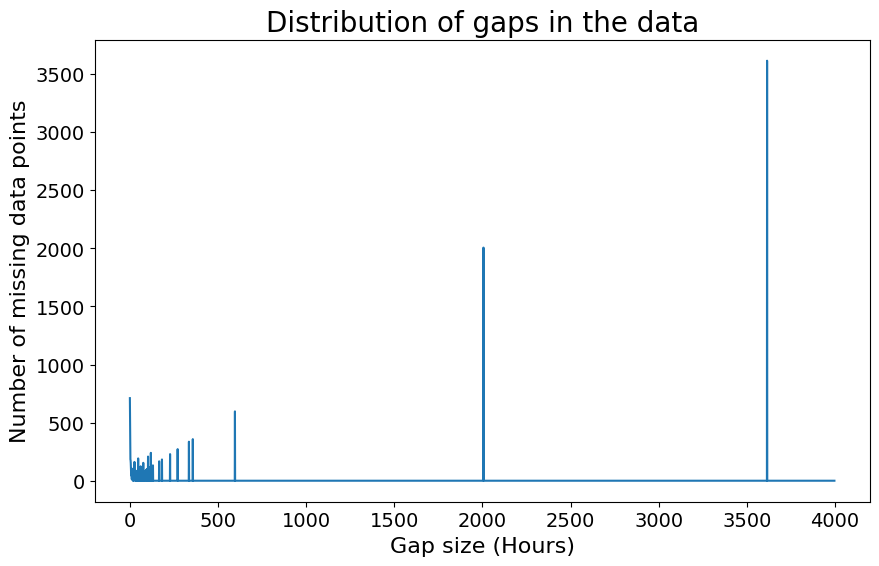

In [21]:
# Trace a distribuição dos tamanhos das lacunas nos dados
utilitariosFaseB_implementacao.plot_distribution_of_gaps(raw_data, target='PM2.5')

## Desenhar uma solução 
### 5. Visualize métodos simples para estimar valores ausentes
#### Simulação de queda do centro por 1 hora
Talvez a maneira mais direta de estimar o valor ausente em seus dados seja simplesmente pegar o último valor conhecido na série e usá-lo para substituir o valor ausente. Outra opção seria usar uma medição de corrente da estação mais próxima (método do vizinho mais próximo).

Execute a próxima célula para gerar uma visualização do resultado do preenchimento dos valores ausentes com o último valor conhecido ou com o método do vizinho mais próximo.

In [22]:
# Especifique a data para plotar
day = datetime(2021, 1, 19)

# Cria um gráfico para exibir a interpolação linear para um intervalo de horas
utilitariosFaseB_implementacao.visualize_missing_values_estimation(raw_data_enriched, day);

interactive(children=(Dropdown(description='Estação', options=('USM', 'BOL', 'SUB', 'TUN', 'LFR', 'PTE', 'MAM'…

## 6. Execute o método do vizinho mais próximo para estabelecer uma linha de base

Com a próxima célula, você executará seu modelo de vizinho mais próximo em lacunas simuladas nos dados PM2,5. A distribuição de lacunas nas quais você testará seu modelo aqui é simulada para ser semelhante à distribuição dos dados reais. Em princípio, o tamanho das lacunas não deveria importar para este método, mas você simulará a distribuição real para consistência com os dados reais.

Você calculará a precisão do seu modelo de linha de base calculando o [Erro Médio Absoluto (MAE)](https://en.wikipedia.org/wiki/Mean_absolute_error). O MAE é apenas a diferença média entre o resultado do seu modelo e a verdade básica, neste caso para PM2,5.

$$MAE = \frac{1}{n} \sum_{i=1}^{n}{|\rm{real}_i - \rm{modelo}_i|}$$
    
Onde "n" é o número de amostras no conjunto de dados de teste

Tenha em mente que MAE é apenas uma métrica de erro potencial que você pode escolher para avaliar seu modelo e, na prática, você pode escolher uma diferente (como erro quadrático médio, por exemplo) dependendo de como você deseja medir o desempenho e do que você pretende. use seu modelo para. Aqui estamos usando o MAE porque é um modelo de medição de desempenho simples e intuitivo, onde a estimativa do erro está nas unidades do que você está tentando estimar, neste caso, os níveis de PM2,5 em microgramas / $\rm{ m}^3$.

Execute a próxima célula para testar o método do vizinho mais próximo e calcular o MAE.

In [23]:
import time

# Marca o início do tempo de execução
start_time = time.time()

# Crie um modelo de vizinho mais próximo e execute-o em seus dados de teste
regression_scores = {}
regression_scores['baseline_model'] = utilitariosFaseB_implementacao.calculate_mae_for_nearest_station(raw_data_enriched, target='PM2.5')
print(regression_scores['baseline_model'])

# Marca o final do tempo de execução
end_time = time.time()

# Calcula e imprime o tempo total de execução
total_time = end_time - start_time
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Tempo total de execução: {int(hours)}h {int(minutes)}min {seconds}seg")

{'MAE': 7.959363917171949}
Tempo total de execução: 0h 1min 7.307296991348267seg


## 7. Prepare os dados para treinar um modelo de rede neural

Agora que estabeleceu uma linha de base, você preparará seu conjunto de dados para treinar e testar um modelo de rede neural para estimar valores ausentes de PM2,5.

### 7.1. Remova valores ausentes e adicione colunas para uso posterior com um modelo de rede neural
Para fazer isso, primeiro você removerá todas as linhas com valores ausentes do conjunto de dados original e, em seguida, simulará lacunas de tamanhos diferentes para testar seu modelo. Antes de remover linhas com valores ausentes, você também adicionará algumas colunas extras ao conjunto de dados para preparar o treinamento de um modelo de rede neural. Essas novas colunas incluem o dia da semana (`day_week`) e a hora do dia (`hour`). A linha de código que define a variável `one_hot` está convertendo o ID da estação em uma representação numérica para indicar de qual estação vem cada medição.

<img src="img/redesneurais.jpg" alt="split_data" width="400"/>

<center><b>Figure 2:</b> Redes Neurais </center>

In [24]:
# Defina a variável que você deseja prever
target = 'PM2.5'

# Cria novas colunas para dia da semana e hora do dia
raw_data_for_imputing = raw_data_enriched.copy()
raw_data_for_imputing['day_week'] = pd.DatetimeIndex(raw_data_for_imputing['DateTime']).weekday
raw_data_for_imputing['hour'] = pd.DatetimeIndex(raw_data_for_imputing['DateTime']).hour

# Crie uma representação numérica do ID da estação e adicione colunas extras ao dataframe
one_hot = pd.get_dummies(raw_data_for_imputing.Station, prefix='Station')
raw_data_for_imputing = raw_data_for_imputing.join(one_hot)

# Faça uma cópia do dataframe antes de descartar linhas com valores ausentes
data_no_missing = raw_data_for_imputing.copy()  
# Elimina todas as linhas contendo valores ausentes
data_no_missing.dropna(inplace=True)
# Imprima o número de valores ausentes na coluna PM2.5 como verificação (deve imprimir 0)
null_remaining = data_no_missing[target].isnull().sum()
if null_remaining == 0: 
    print('Valores ausentes removidos e dados preparados com sucesso!')

Valores ausentes removidos e dados preparados com sucesso!


### 7.2 Divida os dados em conjuntos de treinamento e teste

Para comparar seu modelo de linha de base com um modelo de rede neural, é importante executar o teste no mesmo subconjunto de dados. Nesta etapa, você separará um conjunto de dados de teste e o usará em seu modelo de linha de base e comparará com seu modelo de rede neural.

<img src="img/split_data.png" alt="split_data" width="400"/>

<center><b>Figura 1:</b> Dividindo dados em conjuntos de treinamento e teste </center>

Execute a próxima célula para separar 20% dos seus dados para teste.

In [25]:
train_data, test_data = train_test_split(data_no_missing, test_size=0.20, random_state=57)

print(f'Tamanho do dataset de treino: {train_data.shape}')
print(f'Tamanho do dataset de teste: {test_data.shape}')

Tamanho do dataset de treino: (69925, 31)
Tamanho do dataset de teste: (17482, 31)




    
</details>



## 8. Treine e teste um modelo de rede neural para estimar dados ausentes.

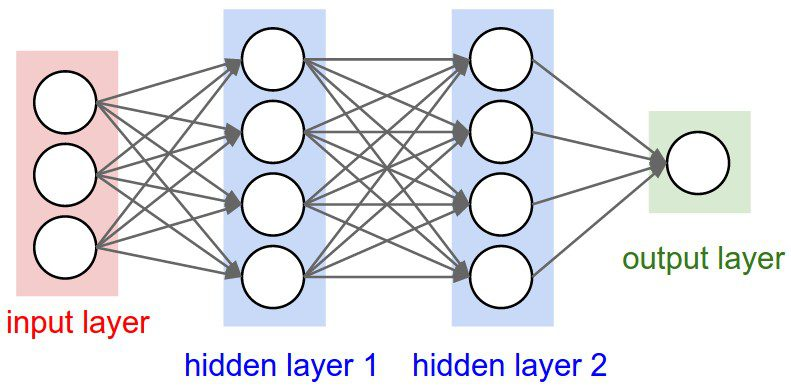


Execute a próxima célula para treinar e testar um modelo de rede neural para estimar valores ausentes de PM2,5. Nesse caso, você precisa treinar a rede neural para aprender como os valores de PM2,5 estão relacionados aos valores de todos os outros poluentes, bem como à hora do dia, dia da semana e localização da estação. Observe que a rede neural que você irá treinar é muito maior que a mostrada na imagem, pois possui 64 e 32 unidades nas duas camadas ocultas.

In [26]:
# Defina os recursos nos quais você baseará suas previsões
pollutants_list = ['PM10','PM2.5','NO','NO2','NOX','CO','OZONE']
pollutants_except_target = [i for i in pollutants_list if i != target]
feature_names = ['day_week', 'hour'] + list(one_hot.columns) + pollutants_except_target

# Definir a arquitetura do modelo de rede neural
model = utilitariosFaseB_implementacao.build_keras_model(input_size=len(feature_names))

# Treine e teste o modelo
model, scaler, mae = utilitariosFaseB_implementacao.train_and_test_model(feature_names, target, train_data, test_data, model)
regression_scores['neural_network_model'] = mae

2023-12-06 08:25:10.051712: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-12-06 08:25:10.153782: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
1093/1093 [==============================] - 1s 624us/step - loss: 39.7057 - mae: 4.6106
Epoch 2/100
1093/1093 [==============================] - 1s 614us/step - loss: 35.7511 - mae: 4.3863
Epoch 3/100
1093/1093 [==============================] - 1s 619us/step - loss: 34.4119 - mae: 4.3014
Epoch 4/100
1093/1093 [==============================] - 1s 602us/step - loss: 33.8189 - mae: 4.2663
Epoch 5/100
1093/1093 [==============================] - 1s 661us/step - loss: 33.3403 - mae: 4.2287
Epoch 6/100
1093/1093 [==============================] - 1s 673us/step - loss: 33.0310 - mae: 4.2120
Epoch 7/100
1093/1093 [==============================] - 1s 634us/step - loss: 32.7649 - mae: 4.1977
Epoch 8/100
1093/1093 [==============================] - 1s 659us/step - loss: 32.3710 - mae: 4.1770
Epoch 9/100
1093/1093 [==============================] - 1s 621us/step - loss: 32.1364 - mae: 4.1622
Epoch 10/100
1093/1093 [==============================] - 1s 627us/step - loss: 32.1316 - m

## Comparar o MAE de vizinho mais próximo com MAE de redeu neural

Compare o **MAE** obtido usando os 2 métodos. Este valor foi obtido usando o mesmo conjunto de testes, portanto é comparável.

In [15]:
# Imprima o resultado do MAE
for model_name, model_score in regression_scores.items():
    print(model_name, ' : ', model_score)

baseline_model  :  {'MAE': 7.959363917171949}
neural_network_model  :  {'MAE': 4.098567722029468}


## 9. Visualize os resultados do seu modelo de linha de base em comparação com a rede neural.

Execute a próxima célula para visualizar os resultados do modelo de linha de base e do modelo de rede neural. Use os menus suspensos para escolher entre diferentes localizações de estações e diferentes "janelas" ou tamanhos de intervalo em horas. Use o controle deslizante para escolher o índice inicial da janela que deseja investigar. Você também pode alterar os valores `start_date` e `end_date` para outras datas em 2021.

In [16]:
start_date = datetime(2021, 2, 1)
end_date = datetime(2021, 2, 3)

utilitariosFaseB_implementacao.create_plot_with_preditions(data_no_missing, model, scaler, feature_names, target,  start_date, end_date)

interactive(children=(Dropdown(description='Station', options=('USM', 'BOL', 'SUB', 'TUN', 'LFR', 'PTE', 'MAM'…

## 10. Estime as medições faltantes dos sensores em todos os poluentes.

Com a primeira linha do código abaixo, você estimará os valores ausentes para todos os poluentes não PM2,5 usando o método dos vizinhos mais próximos. Com a segunda linha, você usará sua rede neural próxima para estimar os valores ausentes para PM2.5. A última linha simplesmente imprime novamente o número de valores faltantes em cada coluna, que deveria ser zero se tudo corresse bem.

In [18]:
# Estimate non-PM2.5 missing values with the nearest neighbor method
# # Estimar valores ausentes não PM2.5 com o método do vizinho mais próximo
imputed_with_baseline_model = utilitariosFaseB_implementacao.impute_nontarget_missing_values_interpolate(raw_data_for_imputing, feature_names, target)
# Estimate missing PM2.5 values with 
# Estimar valores ausentes de PM2.5 com
data_with_imputed = utilitariosFaseB_implementacao.impute_target_missing_values_neural_network(raw_data_for_imputing, model, scaler, imputed_with_baseline_model, target)
# Print out a count of missing data for each column in the dataset with imputed values
# Imprima uma contagem de dados ausentes para cada coluna do conjunto de dados com valores imputados
data_with_imputed[pollutants_list].isnull().sum()

417/417 [==============================] - 0s 513us/step


PM10     0
PM2.5    0
NO       0
NO2      0
NOX      0
CO       0
OZONE    0
dtype: int64

In [19]:
# Imprima uma amostra do dataframe
data_with_imputed.sample(25)

,DateTime,Station,Latitude,Longitude,PM2.5,PM10,NO,NO2,NOX,CO,OZONE,PM2.5_imputed_flag,PM10_imputed_flag,NO_imputed_flag,NO2_imputed_flag,NOX_imputed_flag,CO_imputed_flag,OZONE_imputed_flag
122997,2021-01-15 21:00:00,GYR,4.783750,-74.044139,27.000000,43.00,81.157000,17.419000,98.569000,1.463114,1.698000,None,None,None,None,None,interpolated,None
12265,2021-05-27 01:00:00,BOL,4.735806,-74.125889,5.600000,22.90,3.026000,14.817000,17.843000,0.111940,5.257396,None,None,None,None,None,None,interpolated
136083,2021-07-15 03:00:00,MOV2,4.668000,-74.148500,6.800000,9.10,13.905000,17.727000,31.632000,0.531606,0.000000,None,None,None,None,None,interpolated,None
96846,2021-01-21 06:00:00,JAZ,4.608500,-74.114944,12.200000,33.50,100.088000,23.773000,123.861000,1.658520,1.272000,None,None,None,None,None,None,None
50622,2021-10-12 06:00:00,PTE,4.631767,-74.117483,40.500000,50.60,60.808000,47.293000,108.102000,2.568720,0.920000,None,None,None,None,None,None,None
112692,2021-11-12 12:00:00,7MA,4.645194,-74.061556,23.100000,67.36,40.346000,12.008000,52.354000,1.173120,5.459186,None,interpolated,None,None,None,None,interpolated
113785,2021-12-28 01:00:00,7MA,4.645194,-74.061556,33.400000,39.60,184.823625,9.553077,194.375846,2.151210,5.330472,None,None,interpolated,interpolated,interpolated,interpolated,interpolated
5184,2021-08-05 00:00:00,USM,4.532056,-74.117139,12.700000,17.60,1.738000,6.754000,8.500000,0.228820,16.899000,None,None,None,None,None,None,None
75516,2021-08-15 12:00:00,CDAR,4.658467,-74.083967,7.000000,18.10,4.660000,11.944000,16.605000,0.447800,41.327000,None,None,None,None,None,None,None
80131,2021-02-23 19:00:00,SCR,4.572553,-74.083814,13.000000,25.00,6.888000,12.145000,19.033000,0.314914,18.062000,None,None,None,None,None,interpolated,None


Você pode ver que as colunas de flag incluem valores diferentes: `None` onde há dados originais, `'rede neural'` onde os valores foram imputados com a rede neural e `'interpolados'` onde os valores foram interpolados.

## 11. Visualize os resultados do preenchimento dos valores PM2.5 ausentes

Você pode usar as colunas de sinalização registradas acima para distinguir entre dados originais e estimados e pode visualizar isso executando a célula abaixo.

In [21]:
# Defina uma data de início e término e visualize os valores faltantes que foram imputados
start_date = datetime(2021, 3, 1)
end_date = datetime(2021, 4, 30)
utilitariosFaseB_implementacao.create_time_series_plot(data_with_imputed, start_date, end_date)

interactive(children=(Dropdown(description='Station', options=('USM', 'BOL', 'SUB', 'TUN', 'LFR', 'PTE', 'MAM'…

## 12. Opcional: grave o conjunto de dados resultante em um novo arquivo csv

Finalmente, você pode salvar os dados em um novo arquivo csv para uso na próxima etapa do projeto. Nesse caso, os dados serão fornecidos no próximo laboratório, portanto você não precisa salvá-los aqui, mas incluímos a linha de código abaixo para mostrar como gravar os dados em um arquivo. Se você descomentar o código abaixo (remover o #), poderá executar a célula e clicar no ícone do Jupyter acima para ver o novo arquivo csv em sua pasta com o restante do conteúdo do laboratório.

In [23]:
data_with_imputed.to_csv('data/DadosCompletosIncorporadosV3.csv')

## Ler os dados Imputados

In [24]:
# Ler os dados
raw_data = pd.read_csv('data/DadosCompletosIncorporadosV3.csv')
# Printar a quantidade de linhas de um dataset
print(f'-='*30)
print(f"O dataset contém {len(raw_data)} entradas")
print(f'-='*30)
# Printar as cinco primeiras linhas
raw_data.head(5)

-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
O dataset contém 157680 entradas
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=


,Unnamed: 0,DateTime,Station,Latitude,Longitude,PM2.5,PM10,NO,NO2,NOX,CO,OZONE,PM2.5_imputed_flag,PM10_imputed_flag,NO_imputed_flag,NO2_imputed_flag,NOX_imputed_flag,CO_imputed_flag,OZONE_imputed_flag
0,0,2021-01-01 00:00:00,USM,4.532056,-74.117139,32.7,56.6,7.504,15.962,23.493,0.44924,2.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2021-01-01 01:00:00,USM,4.532056,-74.117139,39.3,59.3,16.560,17.866,34.426,0.69832,1.121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2021-01-01 02:00:00,USM,4.532056,-74.117139,70.8,96.4,22.989,17.802,40.791,0.88243,1.172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2021-01-01 03:00:00,USM,4.532056,-74.117139,81.0,108.3,3.704,9.886,13.591,0.29549,6.565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2021-01-01 04:00:00,USM,4.532056,-74.117139,56.1,87.7,2.098,9.272,11.371,0.16621,9.513,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Ajustar a base de dados para Preparar a aplicação

In [40]:
import pandas as pd

# Carregar o dataset
df = pd.read_csv('data/DadosCompletosIncorporadosV3.csv')

# Remover a coluna "Unnamed: 0"
df.drop('Unnamed: 0', axis=1, inplace=True)

# Converter e formatar a coluna DateTime
# Certificando-se de que a coluna DateTime está no formato correto
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Salvar o novo DataFrame em um arquivo CSV
df.to_csv('data/dadosIncorporadosFinal.csv', index=False)

## Ler os novos dados

In [41]:
# Ler os dados
raw_data = pd.read_csv('data/dadosIncorporadosFinal.csv')
# Printar a quantidade de linhas de um dataset
print(f'-='*30)
print(f"O dataset contém {len(raw_data)} entradas")
print(f'-='*30)
# Printar as cinco primeiras linhas
raw_data.head(5)

-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
O dataset contém 157680 entradas
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=


,DateTime,Station,Latitude,Longitude,PM2.5,PM10,NO,NO2,NOX,CO,OZONE,PM2.5_imputed_flag,PM10_imputed_flag,NO_imputed_flag,NO2_imputed_flag,NOX_imputed_flag,CO_imputed_flag,OZONE_imputed_flag
0,2021-01-01 00:00:00,USM,4.532056,-74.117139,32.7,56.6,7.504,15.962,23.493,0.44924,2.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,USM,4.532056,-74.117139,39.3,59.3,16.560,17.866,34.426,0.69832,1.121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-01 02:00:00,USM,4.532056,-74.117139,70.8,96.4,22.989,17.802,40.791,0.88243,1.172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-01 03:00:00,USM,4.532056,-74.117139,81.0,108.3,3.704,9.886,13.591,0.29549,6.565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-01 04:00:00,USM,4.532056,-74.117139,56.1,87.7,2.098,9.272,11.371,0.16621,9.513,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Etapa C: Implementar a solução

# Qualidade do Ar: Projete (conclua) e Implemente seu Produto

Bem-vindo ao laboratório final deste projeto. Aqui, novamente, você trabalhará com o conjunto de dados com o qual já se familiarizou da rede de monitoramento da qualidade do ar em Bogotá [RMCAB](http://201.245.192.252:81/home/map). Neste caderno, você concluirá as seguintes etapas:

1. Importe pacotes Python
2. Carregue o conjunto de dados com os valores ausentes preenchidos (resultado do último laboratório)
3. Use o método do vizinho mais próximo para fazer um mapa das PM2,5 em Bogotá
4. Teste diferentes valores de k para o método do vizinho mais próximo
5. Use o melhor valor de k para fazer um mapa de PM2,5 em Bogotá
6. Construa uma animação de mapa do PM2.5 em Bogotá
7. Exiba a animação do seu mapa

In [12]:
# Import Python packages.
import folium # package for animations
import folium.plugins as plugins # extras for animations
import pandas as pd # package for reading in and manipulating data
from sklearn.neighbors import KNeighborsRegressor # package for doing KNN
from datetime import datetime # package for manipulating dates

import utiliTariosFaseC # utility functions defined for this lab
import utiliTariosFaseCV2 # utility functions defined for this 

print("All packages imported successfully!")

All packages imported successfully!


## 2. Carregue o conjunto de dados com os valores ausentes preenchidos (resultado do último laboratório)

Execute a próxima célula para ler o conjunto de dados que foi o resultado final do último laboratório, ou seja, um conjunto de dados com todos os valores faltantes para os poluentes preenchidos.

In [32]:
# Load the dataset with missing values filled in.
full_dataset = pd.read_csv('data/full_data_with_imputed_values.csv')
full_dataset['DateTime'] = pd.to_datetime(full_dataset['DateTime'], dayfirst=True)

full_dataset.head(5)


,DateTime,Station,Latitude,Longitude,PM2.5,PM10,NO,NO2,NOX,CO,OZONE,PM2.5_imputed_flag,PM10_imputed_flag,NO_imputed_flag,NO2_imputed_flag,NOX_imputed_flag,CO_imputed_flag,OZONE_imputed_flag
0,2021-01-01 00:00:00,USM,4.532097,-74.116947,32.7,56.6,7.504,15.962,23.493,0.44924,2.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,USM,4.532097,-74.116947,39.3,59.3,16.560,17.866,34.426,0.69832,1.121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-01 02:00:00,USM,4.532097,-74.116947,70.8,96.4,22.989,17.802,40.791,0.88243,1.172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-01 03:00:00,USM,4.532097,-74.116947,81.0,108.3,3.704,9.886,13.591,0.29549,6.565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-01 04:00:00,USM,4.532097,-74.116947,56.1,87.7,2.098,9.272,11.371,0.16621,9.513,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Carregar o dataset
full_dataset = pd.read_csv('data/dadosCompletosFaseCOriginal.csv')

# Para o conjunto de dados dadosIncorporadosFinal.csv
full_dataset['DateTime'] = pd.to_datetime(full_dataset['DateTime'], format='%Y-%m-%d %H:%M:%S')

# Visualizar as primeiras linhas do dataframe
full_dataset.head(5)

ValueError: time data "01/01/2021 00:00" doesn't match format "%Y-%m-%d %H:%M:%S", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## 3. Use o método do vizinho mais próximo para fazer um mapa de PM2,5 em Bogotá
Aqui você usa o método do vizinho mais próximo para estimar os valores dos poluentes nos pontos entre as estações, para poder criar um bom mapa visual da poluição.

In [14]:
# Define a value for k
k = 1
# Define the target pollutant
target = 'PM2.5'
# Define a grid cell size (higher value implies a finer grid)
# Defina um tamanho de célula da grade (valor mais alto implica uma grade mais fina)
n_points_grid = 64
neighbors_model = KNeighborsRegressor(n_neighbors=k, weights = 'distance', metric='sqeuclidean')
# Isolate a single time step from the dataset
#Isole uma única etapa de tempo do conjunto de dados
time_step = datetime.fromisoformat('2021-04-05T08:00:00')
time_step_data = full_dataset[full_dataset['DateTime'] == time_step]
neighbors_model.fit(time_step_data[['Latitude', 'Longitude']], time_step_data[[target]])
# Generate a map of predictions for Bogotá
predictions_xy, dlat, dlon = utiliTariosFaseCV2.predict_on_bogota(neighbors_model, n_points_grid)
utiliTariosFaseCV2.create_heat_map(predictions_xy, time_step_data, dlat, dlon, target)

/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/py

## 4. Teste diferentes valores de k para o método do vizinho mais próximo
Execute as células abaixo para calcular primeiro o erro médio absoluto (MAE) para k=1, ou em outras palavras, o erro associado ao uso de apenas um vizinho mais próximo, como você fez para criar o mapa acima. Depois disso, você executará o mesmo cálculo para diferentes valores de k.

A maneira como você está fazendo isso é semelhante ao que fez no laboratório anterior, onde calculou o MAE para usar medições de estações de sensores próximas para estimar o valor de PM2,5 em qualquer local de estação de sensores. Aqui você avaliará o método mostrado no mapa acima em cada localização de estação de sensor como se a medição dessa estação fosse substituída por um valor da estação vizinha mais próxima e, em seguida, uma média ponderada de k estações vizinhas mais próximas.


O cálculo do erro médio absoluto que está sendo executado pelo código anterior é o seguinte:

$$MAE = \frac{1}{n} \sum_{i=1}^{n}{|\rm{real}_i - \rm{modelo}_i|}$$
    
Onde "n" é o número de amostras no conjunto de dados de teste

In [7]:
# Faça uma estimativa do erro médio absoluto para k=1
utiliTariosFaseC.calculate_mae_for_k(full_dataset, k=1, target_pollutant=target)

7.9667946597067365

## Depois de testar k=1, execute a célula a seguir para testar um intervalo de valores para k.

In [8]:
# Faça uma estimativa do erro médio absoluto (MAE) para um intervalo de valores k.
kmin = 1
kmax = 7

for kneighbors in range(kmin, kmax+1):
    mae = utiliTariosFaseC.calculate_mae_for_k(full_dataset, k=kneighbors, target_pollutant=target)
    print(f'k = {kneighbors}, MAE = {mae}')

k = 1, MAE = 7.9667946597067365
k = 2, MAE = 7.344430373369739
k = 3, MAE = 7.2009935833310825
k = 4, MAE = 7.160703806600688
k = 5, MAE = 7.150753299020979
k = 6, MAE = 7.147187885290036
k = 7, MAE = 7.147022846773627


## 5. Use o melhor valor de k para fazer um mapa de PM2,5 em Bogotá

Execute a célula abaixo para gerar um mapa de valores PM2,5. O mapa mostrará a concentração do poluente escolhido sobre a cidade na `data_final` selecionada. Ao clicar nos círculos do mapa (estações), aparecem gráficos pop-up, mostrando a concentração do poluente no intervalo de tempo selecionado (de `data_inicial` a `data_final`). Você pode alterar os valores de datas e horas ou ` k` para ver como os dados diferem em vários momentos e como o resultado muda dependendo de `k`.

In [10]:
k = 3
start_date = datetime.fromisoformat('2021-01-02T08:00:00')
end_date = datetime.fromisoformat('2021-04-05T08:00:00')

utiliTariosFaseC.create_heat_map_with_date_range(full_dataset, start_date, end_date, k, target)

/media/maykon/Arquivos/4-ProjetoQualidadeDoAr/venvQualidadeAr/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


ZeroDivisionError: float division by zero